<div align="center">

# Laboratorio 5
## Minería de Textos y Análisis de Sentimiento

**Data Science · UVG 2026**

Iris Ayala &nbsp;·&nbsp; Jonathan Díaz &nbsp;·&nbsp; Anggie Quezada

</div>

---

### Sobre este laboratorio

Se trabaja con el dataset **"Disaster Tweets"** (Kaggle), que contiene 7,613 tweets en inglés etiquetados como **desastre real (1)** o **no desastre (0)**. El objetivo es explorar, mediante minería de texto, qué diferencias de vocabulario existen entre ambas clases, como paso previo a la construcción de un futuro clasificador de texto.

El laboratorio se divide en tres partes:

| Parte | Contenido |
|---|---|
| **Parte 1** | Carga de datos y preprocesamiento (limpieza de tweets) |
| **Parte 2A** | Análisis exploratorio: frecuencia de palabras y nubes de palabras |
| **Parte 2B** | N-gramas (bigramas y trigramas) y análisis de contexto |

Cada sección de código va acompañada de una celda de interpretación (**Observación**) que explica qué muestran los resultados y por qué son relevantes.

# PARTE 1: CARGA DE DATOS Y PREPROCESAMIENTO

**Objetivo:** cargar el dataset de tweets, revisar su calidad (nulos, balance de clases) y aplicar una limpieza de texto estándar (minúsculas, sin URLs/menciones/números/stopwords) para dejarlo listo para el análisis de las Partes 2A y 2B.

## Importar Librerías

In [34]:
import pandas as pd
import numpy as np
import re
from nltk.corpus import stopwords
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)

print("Librerías importadas correctamente")

Librerías importadas correctamente


## Cargar Datos

In [35]:
df = pd.read_csv('train.csv')

print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"\nDesastres (1): {(df['target']==1).sum()}")
print(f"No desastres (0): {(df['target']==0).sum()}")
print(f"\nPrimeras filas:")
df.head()

Dataset cargado: 7613 filas, 5 columnas

Desastres (1): 3271
No desastres (0): 4342

Primeras filas:


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


**Observación:** el dataset tiene 7,613 tweets y está moderadamente desbalanceado: 3,271 son desastres reales (43%) y 4,342 no lo son (57%). No es un desbalance severo, pero conviene tenerlo en cuenta más adelante al evaluar un clasificador (por ejemplo, usando F1-score o recall en vez de solo accuracy).

## Exploración Inicial

In [36]:
print("INFORMACIÓN GENERAL")
print("=" * 60)
df.info()

print("\n\nVALORES NULOS")
print("=" * 60)
print(df.isnull().sum())

INFORMACIÓN GENERAL
<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


VALORES NULOS
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


**Observación:** no hay nulos en `text` ni en `target`, así que el análisis de texto puede continuar sin imputaciones. `keyword` solo tiene 61 nulos (0.8%), pero `location` tiene 2,533 (33%) y además es texto libre sin estandarizar (la gente escribe ciudades, países, emojis o cosas inventadas), por lo que no se usará como variable confiable en este análisis.

## Preprocesamiento de Texto

Antes de analizar el vocabulario hay que normalizar el texto. La función `limpiar_tweet` aplica, en orden:

1. **Minúsculas** — para que "Fire" y "fire" cuenten como la misma palabra.
2. **Quitar URLs y menciones (@usuario)** — no aportan significado semántico sobre el evento.
3. **Quitar el símbolo `#` pero conservar la palabra del hashtag** — hashtags como `#earthquake` o `#wildfire` suelen ser justamente las palabras clave del tweet.
4. **Quitar números y puntuación** — reducen ruido sin perder información relevante para este análisis léxico.
5. **Quitar stopwords en inglés** (the, is, and, ...) — son muy frecuentes pero poco informativas para distinguir clases.

In [37]:
stop_words = set(stopwords.words('english'))

def limpiar_tweet(texto):
    """
    Limpia un tweet aplicando transformaciones:
    1. Minúsculas
    2. Quitar URLs
    3. Quitar menciones (@usuario)
    4. Quitar hashtags pero guardar palabra
    5. Quitar números
    6. Quitar puntuación
    7. Quitar espacios múltiples
    8. Quitar stopwords
    """
    texto = texto.lower()
    texto = re.sub(r'http\S+|www\S+', '', texto)
    texto = re.sub(r'@\w+', '', texto)
    texto = re.sub(r'#', '', texto)
    texto = re.sub(r'\d+', '', texto)
    texto = re.sub(r'[^a-z\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stop_words]
    texto = ' '.join(palabras)
    
    return texto

print("Función de limpieza creada")

Función de limpieza creada


## Aplicar Limpieza

In [38]:
print("Limpiando tweets...")
df['text_cleaned'] = df['text'].apply(limpiar_tweet)

print("Ejemplos ANTES y DESPUÉS:")
print("\nANTES:")
print(df['text'].iloc[0])
print("\nDESPUES:")
print(df['text_cleaned'].iloc[0])

# Quitar tweets vacíos
vacios = (df['text_cleaned'].str.len() == 0).sum()
if vacios > 0:
    df = df[df['text_cleaned'].str.len() > 0].reset_index(drop=True)
    print(f"\nTweets vacíos eliminados: {vacios}")

print(f"\nDataset final: {len(df)} tweets")

Limpiando tweets...
Ejemplos ANTES y DESPUÉS:

ANTES:
Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all

DESPUES:
deeds reason earthquake may allah forgive us

Dataset final: 7613 tweets


**Observación:** el ejemplo muestra cómo un tweet crudo con hashtag y mayúsculas se reduce a sus palabras clave ("deeds reason earthquake may allah forgive us"). Ningún tweet quedó vacío tras la limpieza, por lo que se conservan los 7,613 registros originales para las siguientes partes.

## Guardar Dataset Limpio

In [39]:
df.to_csv('train_cleaned.csv', index=False)
print("Dataset limpio guardado como 'train_cleaned.csv'")

Dataset limpio guardado como 'train_cleaned.csv'


---
# PARTE 2A: ANÁLISIS EXPLORATORIO Y FRECUENCIA DE PALABRAS

**Objetivo:** Analizar qué palabras aparecen más en desastres vs no-desastres y visualizar con nubes de palabras.

## Importar Librerías Adicionales

In [40]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

print("Librerías de análisis importadas")

Librerías de análisis importadas


## Calcular Frecuencia de Palabras

In [41]:
# Tweets de DESASTRES
tweets_desastres = df[df['target'] == 1]['text_cleaned']
texto_desastres = ' '.join(tweets_desastres.values)
palabras_desastres = texto_desastres.split()
frecuencia_desastres = Counter(palabras_desastres)
top_15_desastres = frecuencia_desastres.most_common(15)

print("TOP 15 PALABRAS EN TWEETS DE DESASTRES")
print("=" * 50)
for i, (palabra, freq) in enumerate(top_15_desastres, 1):
    print(f"{i:2}. {palabra:15} -> {freq:5} veces")

# Tweets de NO-DESASTRES
tweets_no_desastres = df[df['target'] == 0]['text_cleaned']
texto_no_desastres = ' '.join(tweets_no_desastres.values)
palabras_no_desastres = texto_no_desastres.split()
frecuencia_no_desastres = Counter(palabras_no_desastres)
top_15_no_desastres = frecuencia_no_desastres.most_common(15)

print("\n\nTOP 15 PALABRAS EN TWEETS DE NO-DESASTRES")
print("=" * 50)
for i, (palabra, freq) in enumerate(top_15_no_desastres, 1):
    print(f"{i:2}. {palabra:15} -> {freq:5} veces")

TOP 15 PALABRAS EN TWEETS DE DESASTRES
 1. fire            ->   180 veces
 2. news            ->   138 veces
 3. via             ->   121 veces
 4. disaster        ->   117 veces
 5. california      ->   111 veces
 6. suicide         ->   110 veces
 7. police          ->   107 veces
 8. amp             ->   107 veces
 9. people          ->   105 veces
10. killed          ->    93 veces
11. like            ->    92 veces
12. pm              ->    89 veces
13. hiroshima       ->    89 veces
14. fires           ->    85 veces
15. storm           ->    85 veces


TOP 15 PALABRAS EN TWEETS DE NO-DESASTRES
 1. like            ->   253 veces
 2. im              ->   248 veces
 3. amp             ->   193 veces
 4. new             ->   170 veces
 5. get             ->   163 veces
 6. dont            ->   154 veces
 7. one             ->   128 veces
 8. body            ->   113 veces
 9. via             ->    99 veces
10. would           ->    97 veces
11. video           ->    96 veces
12. lov

**Observación:** en **desastres** predominan palabras concretas ligadas a eventos catastróficos: `fire` (180), `disaster` (117), `california` (111), `killed` (93), `storm` (85). En **no-desastres** predominan palabras conversacionales y coloquiales: `like` (253), `im` (248), `dont` (154), `love` (90) — típicas del habla cotidiana en redes sociales. Palabras como `via`, `amp`, `people` aparecen en ambos top-15, por lo que por sí solas no son buenas discriminantes; se necesita una medida relativa (ver la sección siguiente).

## Gráfico Comparativo: Top 15 Palabras

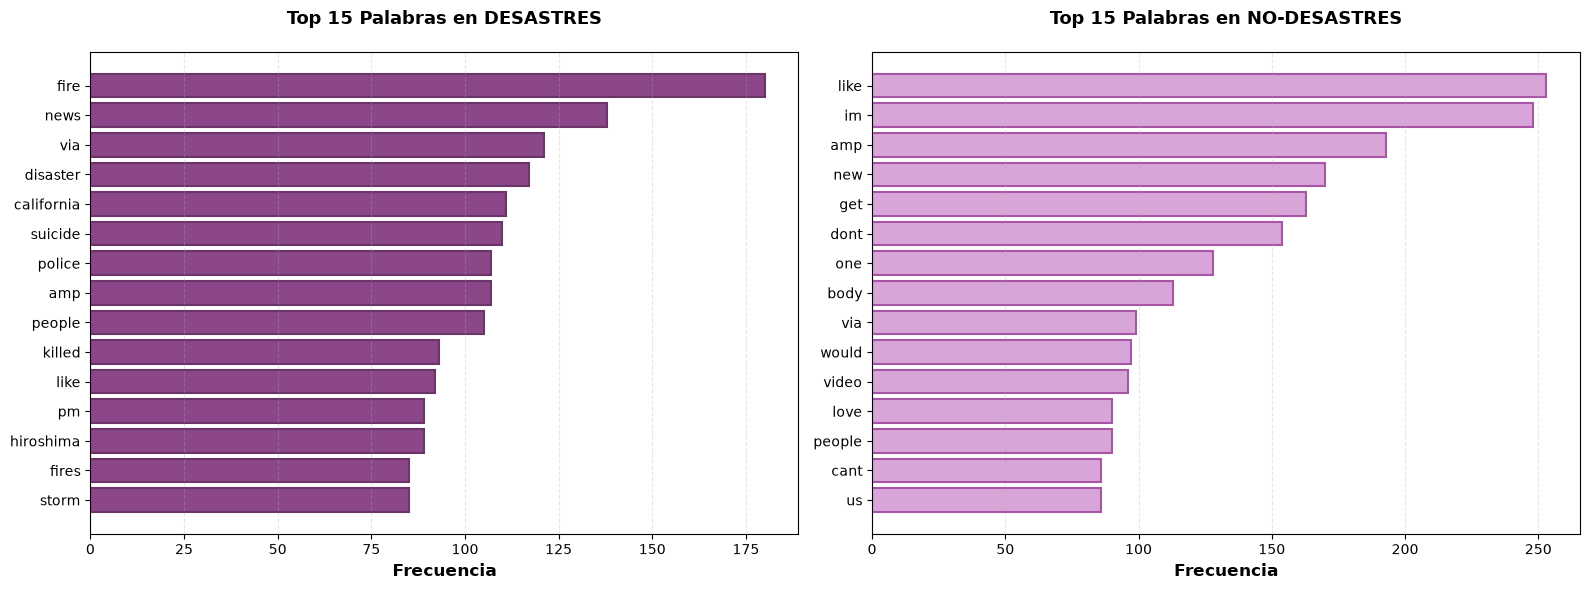

Gráfico guardado: frecuencia_palabras_comparacion.png


In [42]:
palabras_d = [p[0] for p in top_15_desastres]
freq_d = [p[1] for p in top_15_desastres]
palabras_nd = [p[0] for p in top_15_no_desastres]
freq_nd = [p[1] for p in top_15_no_desastres]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

color_desastres = '#8B4789'
color_no_desastres = '#D8A5D8'

axes[0].barh(palabras_d, freq_d, color=color_desastres, edgecolor='#6B3569', linewidth=1.5)
axes[0].set_xlabel('Frecuencia', fontsize=12, fontweight='bold')
axes[0].set_title('Top 15 Palabras en DESASTRES', fontsize=13, fontweight='bold', pad=20)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

axes[1].barh(palabras_nd, freq_nd, color=color_no_desastres, edgecolor='#A855A8', linewidth=1.5)
axes[1].set_xlabel('Frecuencia', fontsize=12, fontweight='bold')
axes[1].set_title('Top 15 Palabras en NO-DESASTRES', fontsize=13, fontweight='bold', pad=20)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('frecuencia_palabras_comparacion.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado: frecuencia_palabras_comparacion.png")

El gráfico confirma visualmente lo anterior: las barras de la izquierda (desastres) están dominadas por sustantivos de eventos, mientras que las de la derecha (no-desastres) están dominadas por verbos/pronombres de uso cotidiano.

## Análisis de Palabras Discriminantes

In [43]:
print("\nPALABRAS QUE DISTINGUEN DESASTRES")
print("=" * 60)

ratios = {}
for palabra, freq_d in frecuencia_desastres.most_common(200):
    freq_nd = frecuencia_no_desastres.get(palabra, 1)
    ratio = freq_d / freq_nd
    ratios[palabra] = {'desastres': freq_d, 'no_desastres': freq_nd, 'ratio': ratio}

palabras_ordenadas = sorted(ratios.items(), key=lambda x: x[1]['ratio'], reverse=True)

print(f"{'Palabra':15} {'Desastres':15} {'No-Desastres':15} {'Ratio':10}")
print("-" * 60)
for palabra, datos in palabras_ordenadas[:10]:
    print(f"{palabra:15} {datos['desastres']:15} {datos['no_desastres']:15} {datos['ratio']:10.2f}")

print("\n\nPALABRAS QUE DISTINGUEN NO-DESASTRES")
print("=" * 60)

palabras_ordenadas_inverso = sorted(palabras_ordenadas, key=lambda x: x[1]['ratio'])

print(f"{'Palabra':15} {'No-Desastres':15} {'Desastres':15} {'Ratio':10}")
print("-" * 60)
for palabra, datos in palabras_ordenadas_inverso[:10]:
    ratio_inv = datos['no_desastres'] / datos['desastres'] if datos['desastres'] > 0 else 0
    print(f"{palabra:15} {datos['no_desastres']:15} {datos['desastres']:15} {ratio_inv:10.2f}")


PALABRAS QUE DISTINGUEN DESASTRES
Palabra         Desastres       No-Desastres    Ratio     
------------------------------------------------------------
hiroshima                    89               1      89.00
mh                           72               1      72.00
northern                     64               1      64.00
legionnaires                 62               1      62.00
bomber                       60               1      60.00
debris                       50               1      50.00
malaysia                     49               1      49.00
severe                       47               1      47.00
spill                        42               1      42.00
derailment                   41               1      41.00


PALABRAS QUE DISTINGUEN NO-DESASTRES
Palabra         No-Desastres    Desastres       Ratio     
------------------------------------------------------------
im                          248              58       4.28
know                         85      

**Observación:** palabras como `hiroshima` (ratio 89), `mh` (72, referencia al vuelo MH370/MH17 de Malaysia Airlines), `legionnaires` (62) y `bomber` (60) aparecen casi exclusivamente en tweets de desastres. Esto sugiere que el dataset no contiene descripciones genéricas de "desastre", sino tweets sobre **eventos noticiosos concretos** (el brote de legionela, la desaparición del vuelo de Malaysia Airlines, atentados, derrames de petróleo, etc.).

En el extremo opuesto, palabras como `im`, `know`, `new`, `got`, `would`, `dont`, `like` distinguen el habla cotidiana: son muy comunes en general y hasta 4 veces más frecuentes en no-desastres que en desastres. Esta separación tan marcada es una buena señal de que el problema es resoluble con un modelo basado en vocabulario (bag-of-words / TF-IDF).

## Crear Nubes de Palabras

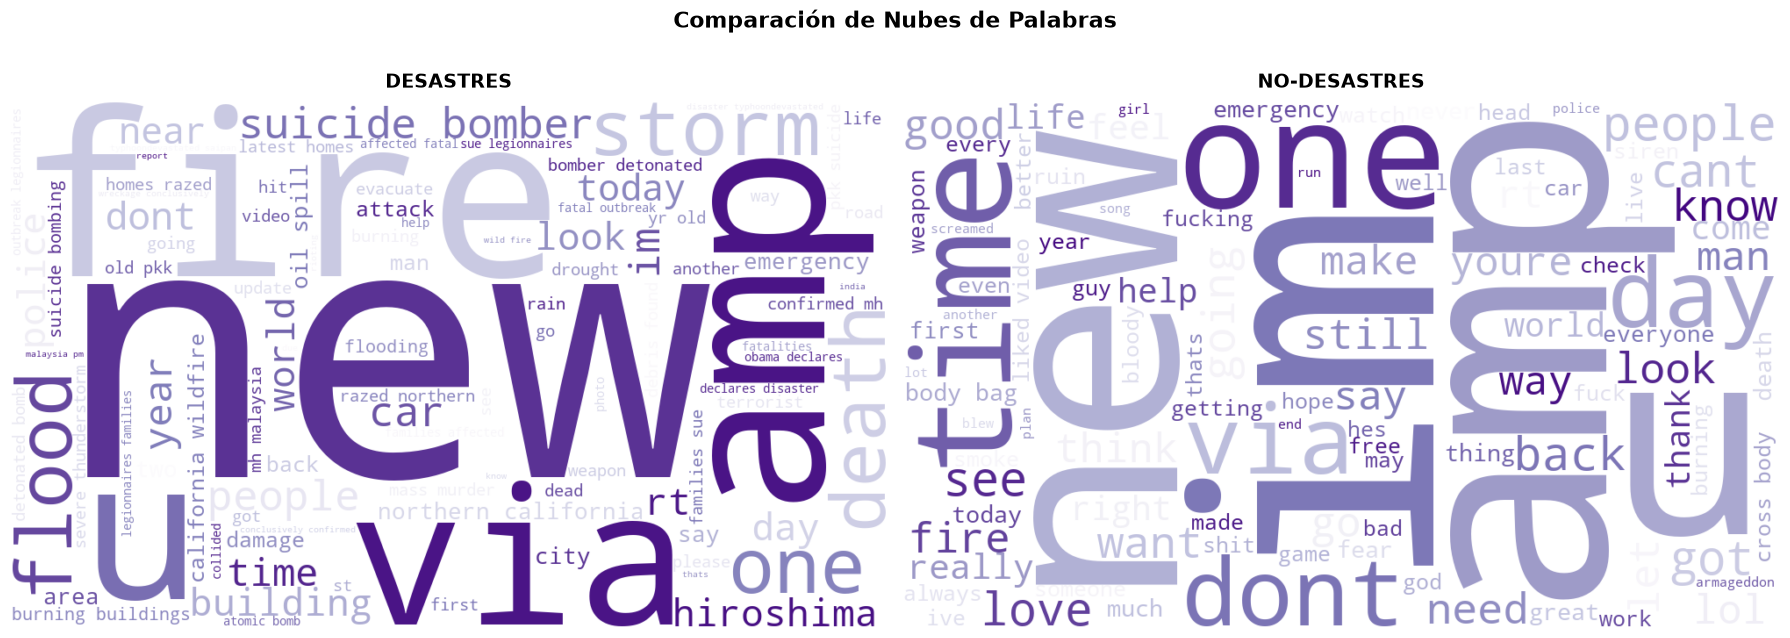

Gráfico guardado: wordcloud_comparacion.png


In [44]:
wordcloud_desastres = WordCloud(
    width=1000, height=600,
    background_color='white',
    colormap='Purples',
    max_words=100,
    relative_scaling=0.5,
    min_font_size=10
).generate(texto_desastres)

wordcloud_no_desastres = WordCloud(
    width=1000, height=600,
    background_color='white',
    colormap='Purples',
    max_words=100,
    relative_scaling=0.5,
    min_font_size=10
).generate(texto_no_desastres)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(wordcloud_desastres, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('DESASTRES', fontsize=14, fontweight='bold', pad=10)

axes[1].imshow(wordcloud_no_desastres, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('NO-DESASTRES', fontsize=14, fontweight='bold', pad=10)

plt.suptitle('Comparación de Nubes de Palabras', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('wordcloud_comparacion.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado: wordcloud_comparacion.png")

Las nubes de palabras resumen visualmente lo mismo: vocabulario de emergencia y lugares/eventos concretos en desastres, y lenguaje casual/emocional en no-desastres.

## Análisis de Palabras Compartidas vs Exclusivas

In [45]:
palabras_desastres_set = set(frecuencia_desastres.keys())
palabras_no_desastres_set = set(frecuencia_no_desastres.keys())

palabras_comunes = palabras_desastres_set & palabras_no_desastres_set
palabras_solo_desastres = palabras_desastres_set - palabras_no_desastres_set
palabras_solo_no_desastres = palabras_no_desastres_set - palabras_desastres_set

print("ANÁLISIS DE PALABRAS")
print("=" * 60)
print(f"Palabras únicas en DESASTRES: {len(palabras_desastres_set)}")
print(f"Palabras únicas en NO-DESASTRES: {len(palabras_no_desastres_set)}")
print(f"\nPalabras en AMBAS: {len(palabras_comunes)}")
print(f"Palabras SOLO en desastres: {len(palabras_solo_desastres)}")
print(f"Palabras SOLO en no-desastres: {len(palabras_solo_no_desastres)}")

print(f"\nEjemplos de palabras EXCLUSIVAS de desastres:")
print(sorted(list(palabras_solo_desastres))[:20])

print(f"\nEjemplos de palabras EXCLUSIVAS de no-desastres:")
print(sorted(list(palabras_solo_no_desastres))[:20])

ANÁLISIS DE PALABRAS
Palabras únicas en DESASTRES: 8006
Palabras únicas en NO-DESASTRES: 10372

Palabras en AMBAS: 3805
Palabras SOLO en desastres: 4201
Palabras SOLO en no-desastres: 6567

Ejemplos de palabras EXCLUSIVAS de desastres:
['aaaaaaallll', 'aaaaaand', 'aaarrrgghhh', 'aal', 'aampb', 'aan', 'aashiqui', 'abbswinston', 'abc', 'abcnews', 'abcs', 'aberystwythshrewsbury', 'abes', 'abha', 'abia', 'ableg', 'aboard', 'abomb', 'abombed', 'abouts']

Ejemplos de palabras EXCLUSIVAS de no-desastres:
['aaaa', 'aampw', 'aannnnd', 'aar', 'ab', 'abandoning', 'abbandoned', 'abbott', 'abbruchsimulator', 'abceyewitness', 'aberdeen', 'abject', 'abomination', 'abortions', 'abstract', 'absurdly', 'abused', 'academia', 'accepts', 'access']


**Observación:** de las 8,006 palabras únicas en desastres y las 10,372 en no-desastres, solo 3,805 se comparten entre ambas clases. Es decir, gran parte del vocabulario de cada clase es exclusivo suyo (4,201 palabras solo en desastres, 6,567 solo en no-desastres). Ese bajo solapamiento es una señal fuerte de separabilidad léxica, aunque hay que tomarlo con cautela: muchas de esas palabras "exclusivas" son ruido (nombres de usuario, errores tipográficos, hashtags mal cortados) más que patrones lingüísticos generalizables.

## Visualización: Palabras por Categoría

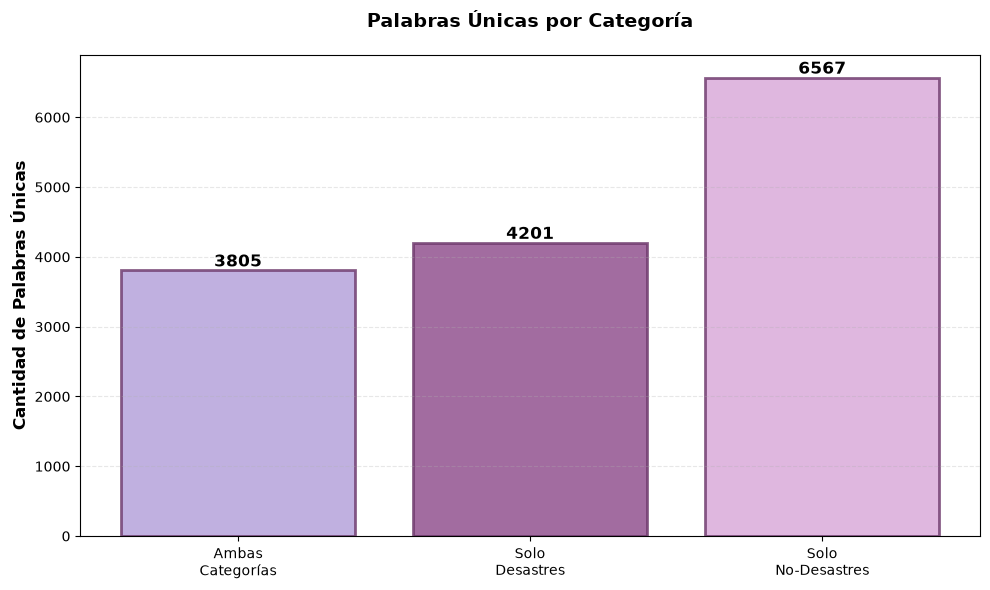

Gráfico guardado: palabras_analisis.png


In [46]:
categorias = ['Ambas\nCategorías', 'Solo\nDesastres', 'Solo\nNo-Desastres']
cantidades = [len(palabras_comunes), len(palabras_solo_desastres), len(palabras_solo_no_desastres)]
colores = ['#B19CD9', '#8B4789', '#D8A5D8']

fig, ax = plt.subplots(figsize=(10, 6))
barras = ax.bar(categorias, cantidades, color=colores, edgecolor='#6B3569', linewidth=2, alpha=0.8)

for barra, cantidad in zip(barras, cantidades):
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2., altura,
            f'{int(cantidad)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Cantidad de Palabras Únicas', fontsize=12, fontweight='bold')
ax.set_title('Palabras Únicas por Categoría', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('palabras_analisis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado: palabras_analisis.png")

El gráfico deja ver que la mayoría del vocabulario (10,768 de 14,573 palabras únicas totales) pertenece a una sola clase, y solo una minoría (3,805) se comparte entre ambas.

---
# PARTE 2B: N-GRAMAS Y ANÁLISIS DE CONTEXTO

**Objetivo:** ir más allá de palabras sueltas y analizar secuencias de 2 y 3 palabras (bigramas y trigramas) para capturar el contexto en el que aparece cada término, y comparar la riqueza de vocabulario entre desastres y no-desastres.

## Preparar Textos por Categoría

In [47]:
# Textos separados por categoría
texto_desastres = ' '.join(df[df['target'] == 1]['text_cleaned'].values)
texto_no_desastres = ' '.join(df[df['target'] == 0]['text_cleaned'].values)

print(f"Caracteres en desastres: {len(texto_desastres)}")
print(f"Caracteres en no-desastres: {len(texto_no_desastres)}")

Caracteres en desastres: 217494
Caracteres en no-desastres: 246208


**Observación:** el corpus de no-desastres tiene más caracteres en total (246,208 vs 217,494) porque también tiene más tweets (4,342 vs 3,271); en promedio ambos corpus tienen una longitud de tweet similar.

## Función para Generar N-gramas

In [48]:
def generar_ngramas(texto, n):
    """
    Genera n-gramas de un texto.
    
    Ejemplo:
    - n=1: forest, fire, near (unigramas)
    - n=2: forest fire, fire near (bigramas)
    - n=3: forest fire near (trigramas)
    """
    palabras = texto.split()
    ngramas = []
    for i in range(len(palabras) - n + 1):
        ngrama = ' '.join(palabras[i:i+n])
        ngramas.append(ngrama)
    return ngramas

print("Función de n-gramas creada")

Función de n-gramas creada


## Generar y Analizar Bigramas en DESASTRES

In [49]:
bigramas_desastres = generar_ngramas(texto_desastres, 2)
frecuencia_bigramas_d = Counter(bigramas_desastres)
top_15_bigramas_d = frecuencia_bigramas_d.most_common(15)

print("TOP 15 BIGRAMAS EN TWEETS DE DESASTRES")
print("=" * 60)
for i, (bigrama, freq) in enumerate(top_15_bigramas_d, 1):
    print(f"{i:2}. {bigrama:30} -> {freq:4} veces")

TOP 15 BIGRAMAS EN TWEETS DE DESASTRES
 1. suicide bomber                 ->   59 veces
 2. northern california            ->   41 veces
 3. oil spill                      ->   38 veces
 4. burning buildings              ->   35 veces
 5. suicide bombing                ->   34 veces
 6. california wildfire            ->   34 veces
 7. bomber detonated               ->   30 veces
 8. confirmed mh                   ->   29 veces
 9. yr old                         ->   29 veces
10. homes razed                    ->   29 veces
11. latest homes                   ->   28 veces
12. razed northern                 ->   28 veces
13. pkk suicide                    ->   28 veces
14. detonated bomb                 ->   28 veces
15. mh malaysia                    ->   27 veces


**Observación:** los bigramas más frecuentes en desastres son fragmentos de eventos noticiosos concretos: `suicide bomber` (59), `suicide bombing` (34), `oil spill` (38), `california wildfire` (34), `burning buildings` (35). Confirma lo visto con palabras sueltas: el dataset agrupa tweets sobre incidentes específicos, no menciones genéricas de "desastre".

## Generar y Analizar Bigramas en NO-DESASTRES

In [50]:
bigramas_no_desastres = generar_ngramas(texto_no_desastres, 2)
frecuencia_bigramas_nd = Counter(bigramas_no_desastres)
top_15_bigramas_nd = frecuencia_bigramas_nd.most_common(15)

print("TOP 15 BIGRAMAS EN TWEETS DE NO-DESASTRES")
print("=" * 60)
for i, (bigrama, freq) in enumerate(top_15_bigramas_nd, 1):
    print(f"{i:2}. {bigrama:30} -> {freq:4} veces")

TOP 15 BIGRAMAS EN TWEETS DE NO-DESASTRES
 1. cross body                     ->   38 veces
 2. liked video                    ->   34 veces
 3. full read                      ->   28 veces
 4. body bag                       ->   27 veces
 5. body bagging                   ->   23 veces
 6. burning buildings              ->   23 veces
 7. looks like                     ->   21 veces
 8. body bags                      ->   21 veces
 9. reddit quarantine              ->   21 veces
10. feel like                      ->   20 veces
11. content policy                 ->   20 veces
12. quarantine offensive           ->   19 veces
13. offensive content              ->   18 veces
14. dont know                      ->   17 veces
15. pick fan                       ->   17 veces


**Observación:** en no-desastres destacan bigramas de un evento puntual y viral en Reddit ("reddit quarantine", "content policy", "quarantine offensive") y lenguaje coloquial ("looks like", "feel like", "dont know"). Llama la atención que `burning buildings` (23 veces) también aparezca aquí: probablemente por un uso figurado/metafórico fuera de un contexto real de desastre, lo que ilustra la ambigüedad que un clasificador tendría que resolver.

## Gráfico Comparativo: Bigramas

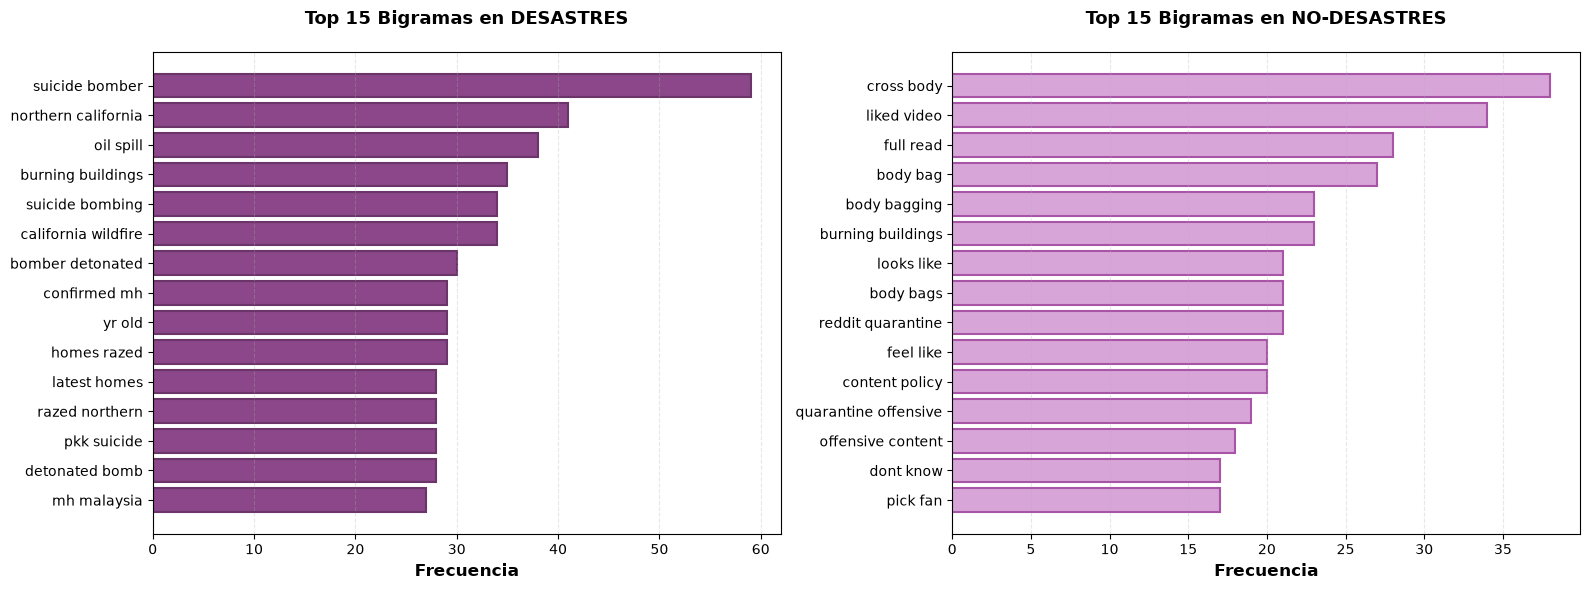

Gráfico guardado: bigramas_comparacion.png


In [51]:
bigramas_d_list = [b[0] for b in top_15_bigramas_d]
freq_bigramas_d = [b[1] for b in top_15_bigramas_d]

bigramas_nd_list = [b[0] for b in top_15_bigramas_nd]
freq_bigramas_nd = [b[1] for b in top_15_bigramas_nd]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

color_d = '#8B4789'
color_nd = '#D8A5D8'

axes[0].barh(bigramas_d_list, freq_bigramas_d, color=color_d, edgecolor='#6B3569', linewidth=1.5)
axes[0].set_xlabel('Frecuencia', fontsize=12, fontweight='bold')
axes[0].set_title('Top 15 Bigramas en DESASTRES', fontsize=13, fontweight='bold', pad=20)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

axes[1].barh(bigramas_nd_list, freq_bigramas_nd, color=color_nd, edgecolor='#A855A8', linewidth=1.5)
axes[1].set_xlabel('Frecuencia', fontsize=12, fontweight='bold')
axes[1].set_title('Top 15 Bigramas en NO-DESASTRES', fontsize=13, fontweight='bold', pad=20)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('bigramas_comparacion.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado: bigramas_comparacion.png")

El gráfico visualiza la brecha temática: bigramas de eventos de emergencia a la izquierda vs. bigramas de una controversia puntual de Reddit y lenguaje casual a la derecha.

## Análisis de Bigramas Discriminantes

In [52]:
print("\nBIGRAMAS QUE DISTINGUEN DESASTRES")
print("=" * 70)

ratios_bigramas = {}
for bigrama, freq_d in frecuencia_bigramas_d.most_common(100):
    freq_nd = frecuencia_bigramas_nd.get(bigrama, 1)
    ratio = freq_d / freq_nd
    ratios_bigramas[bigrama] = {'desastres': freq_d, 'no_desastres': freq_nd, 'ratio': ratio}

bigramas_ordenados = sorted(ratios_bigramas.items(), key=lambda x: x[1]['ratio'], reverse=True)

print(f"{'Bigrama':35} {'Desastres':12} {'No-Des':10} {'Ratio':8}")
print("-" * 70)
for bigrama, datos in bigramas_ordenados[:10]:
    print(f"{bigrama:35} {datos['desastres']:12} {datos['no_desastres']:10} {datos['ratio']:8.2f}")

print("\n\nBIGRAMAS QUE DISTINGUEN NO-DESASTRES")
print("=" * 70)

bigramas_ordenados_inverso = sorted(bigramas_ordenados, key=lambda x: x[1]['ratio'])

print(f"{'Bigrama':35} {'No-Des':10} {'Desastres':12} {'Ratio':8}")
print("-" * 70)
for bigrama, datos in bigramas_ordenados_inverso[:10]:
    ratio_inv = datos['no_desastres'] / datos['desastres'] if datos['desastres'] > 0 else 0
    print(f"{bigrama:35} {datos['no_desastres']:10} {datos['desastres']:12} {ratio_inv:8.2f}")


BIGRAMAS QUE DISTINGUEN DESASTRES
Bigrama                             Desastres    No-Des     Ratio   
----------------------------------------------------------------------
suicide bomber                                59          1    59.00
northern california                           41          1    41.00
oil spill                                     38          1    38.00
suicide bombing                               34          1    34.00
california wildfire                           34          1    34.00
bomber detonated                              30          1    30.00
confirmed mh                                  29          1    29.00
yr old                                        29          1    29.00
homes razed                                   29          1    29.00
latest homes                                  28          1    28.00


BIGRAMAS QUE DISTINGUEN NO-DESASTRES
Bigrama                             No-Des     Desastres    Ratio   
---------------------------

**Observación:** los bigramas con mayor ratio a favor de desastres (`suicide bomber`, `northern california`, `oil spill`, `california wildfire`, con ratios entre 30 y 59) vuelven a apuntar a eventos noticiosos concretos.

**Importante:** en la tabla "BIGRAMAS QUE DISTINGUEN NO-DESASTRES", nótese que en **todas** las filas la columna `Desastres` es mayor que la columna `No-Des` (ej. `wild fires`: 2 en no-desastres vs. 24 en desastres). Esto ocurre porque esa tabla se construyó solo a partir de los 100 bigramas *más frecuentes en desastres*; dentro de ese subconjunto se buscaron los de menor ratio, pero ninguno resultó realmente más común en no-desastres. Es una limitación de la metodología (y de la escasez de datos a nivel de bigrama) más que un hallazgo de bigramas "propios" de no-desastres, a diferencia del análisis por palabra individual (Parte 2A, sección 4), donde sí se encontraron palabras genuinamente más frecuentes en no-desastres.

## Generar y Analizar Trigramas en DESASTRES

In [53]:
trigramas_desastres = generar_ngramas(texto_desastres, 3)
frecuencia_trigramas_d = Counter(trigramas_desastres)
top_15_trigramas_d = frecuencia_trigramas_d.most_common(15)

print("TOP 15 TRIGRAMAS EN TWEETS DE DESASTRES")
print("=" * 70)
for i, (trigrama, freq) in enumerate(top_15_trigramas_d, 1):
    print(f"{i:2}. {trigrama:45} -> {freq:4} veces")

TOP 15 TRIGRAMAS EN TWEETS DE DESASTRES
 1. suicide bomber detonated                      ->   30 veces
 2. northern california wildfire                  ->   29 veces
 3. latest homes razed                            ->   28 veces
 4. homes razed northern                          ->   28 veces
 5. pkk suicide bomber                            ->   28 veces
 6. bomber detonated bomb                         ->   28 veces
 7. razed northern california                     ->   27 veces
 8. yr old pkk                                    ->   27 veces
 9. old pkk suicide                               ->   27 veces
10. families sue legionnaires                     ->   26 veces
11. families affected fatal                       ->   26 veces
12. affected fatal outbreak                       ->   26 veces
13. obama declares disaster                       ->   25 veces
14. declares disaster typhoondevastated           ->   25 veces
15. disaster typhoondevastated saipan             ->   25 veces


**Observación:** varios trigramas de desastres son fragmentos consecutivos de una misma oración repetida muchas veces (`obama declares disaster` → `declares disaster typhoondevastated` → `disaster typhoondevastated saipan`), lo que indica que un solo tweet viral/retuiteado sobre un evento específico (un tifón en Saipán) domina el conteo. Hay que tenerlo presente: la alta frecuencia de un trigrama puede deberse a un único evento repetido y no a un patrón lingüístico general de "desastre".

## Generar y Analizar Trigramas en NO-DESASTRES

In [54]:
trigramas_no_desastres = generar_ngramas(texto_no_desastres, 3)
frecuencia_trigramas_nd = Counter(trigramas_no_desastres)
top_15_trigramas_nd = frecuencia_trigramas_nd.most_common(15)

print("TOP 15 TRIGRAMAS EN TWEETS DE NO-DESASTRES")
print("=" * 70)
for i, (trigrama, freq) in enumerate(top_15_trigramas_nd, 1):
    print(f"{i:2}. {trigrama:45} -> {freq:4} veces")

TOP 15 TRIGRAMAS EN TWEETS DE NO-DESASTRES
 1. cross body bag                                ->   19 veces
 2. reddit quarantine offensive                   ->   19 veces
 3. quarantine offensive content                  ->   18 veces
 4. pick fan army                                 ->   17 veces
 5. reddits new content                           ->   16 veces
 6. new content policy                            ->   16 veces
 7. chinas stock market                           ->   16 veces
 8. stock market crash                            ->   16 veces
 9. full read ebay                                ->   15 veces
10. ignition knock detonation                     ->   15 veces
11. content policy goes                           ->   15 veces
12. policy goes effect                            ->   15 veces
13. goes effect many                              ->   15 veces
14. effect many horrible                          ->   15 veces
15. many horrible subreddits                      ->   15 vec

**Observación:** ocurre el mismo patrón de "cadena de un solo tuit": los trigramas 1 a 5 encajan en una sola oración sobre el cambio de política de contenido de Reddit (`reddit quarantine offensive` → ... → `many horrible subreddits`), y los trigramas 7 a 9 en otra sobre la caída del mercado bursátil chino. Confirma que gran parte de la "riqueza" de trigramas proviene de un puñado de tweets retuiteados masivamente, no de mucha variedad de eventos distintos.

## Comparación de N-gramas (Uni/Bi/Trigramas)

In [55]:
# Generar unigramas también
unigramas_desastres = generar_ngramas(texto_desastres, 1)
frecuencia_unigramas_d = Counter(unigramas_desastres)

unigramas_no_desastres = generar_ngramas(texto_no_desastres, 1)
frecuencia_unigramas_nd = Counter(unigramas_no_desastres)

print("\nCOMPARACIÓN: CANTIDAD DE N-GRAMAS ÚNICOS")
print("=" * 70)

datos_ngramas = {
    'Tipo': ['Unigramas (1)', 'Bigramas (2)', 'Trigramas (3)'],
    'En Desastres': [
        len(frecuencia_unigramas_d),
        len(frecuencia_bigramas_d),
        len(frecuencia_trigramas_d)
    ],
    'En No-Desastres': [
        len(frecuencia_unigramas_nd),
        len(frecuencia_bigramas_nd),
        len(frecuencia_trigramas_nd)
    ]
}

df_ngramas = pd.DataFrame(datos_ngramas)
print(df_ngramas.to_string(index=False))


COMPARACIÓN: CANTIDAD DE N-GRAMAS ÚNICOS
         Tipo  En Desastres  En No-Desastres
Unigramas (1)          8006            10372
 Bigramas (2)         22048            31073
Trigramas (3)         24303            33155


**Observación:** el número de n-gramas únicos crece con el orden (8,006 → 22,048 → 24,303 en desastres), como es esperable al combinar más palabras. Sin embargo, el crecimiento se frena entre bigramas y trigramas (+10%, contra +175% entre uni y bigramas), señal de que el corpus es finito y de que —como se vio arriba— varias secuencias largas se repiten por retweets del mismo tuit viral en vez de aportar combinaciones nuevas.

## Visualizar Riqueza de N-gramas

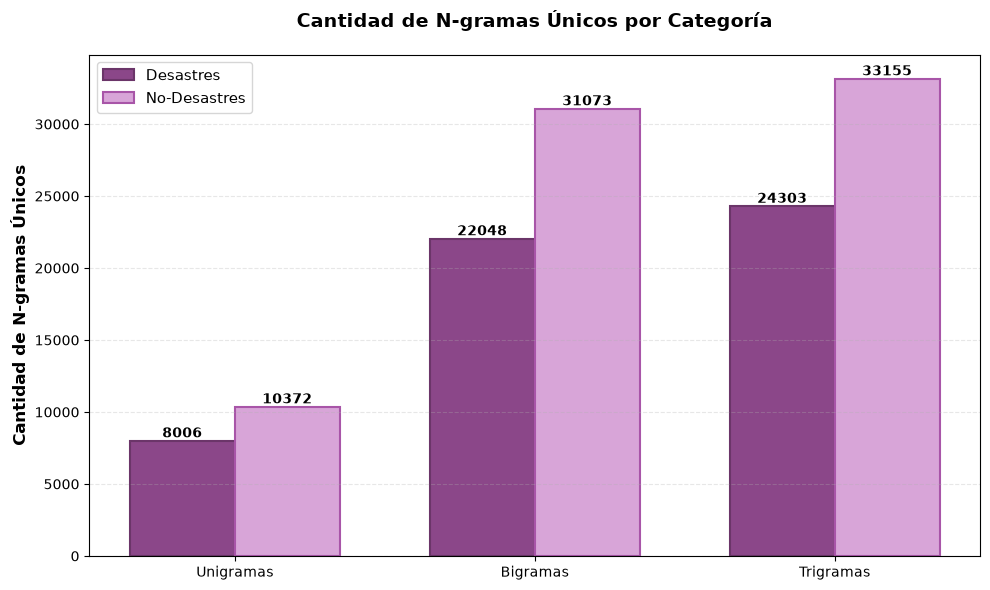

Gráfico guardado: ngramas_cantidad.png


In [56]:
import numpy as np

tipos = ['Unigramas', 'Bigramas', 'Trigramas']
desastres_counts = [
    len(frecuencia_unigramas_d),
    len(frecuencia_bigramas_d),
    len(frecuencia_trigramas_d)
]
no_desastres_counts = [
    len(frecuencia_unigramas_nd),
    len(frecuencia_bigramas_nd),
    len(frecuencia_trigramas_nd)
]

x = np.arange(len(tipos))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

barras1 = ax.bar(x - width/2, desastres_counts, width, label='Desastres',
                  color='#8B4789', edgecolor='#6B3569', linewidth=1.5)
barras2 = ax.bar(x + width/2, no_desastres_counts, width, label='No-Desastres',
                  color='#D8A5D8', edgecolor='#A855A8', linewidth=1.5)

for barras in [barras1, barras2]:
    for barra in barras:
        altura = barra.get_height()
        ax.text(barra.get_x() + barra.get_width()/2., altura,
                f'{int(altura)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Cantidad de N-gramas Únicos', fontsize=12, fontweight='bold')
ax.set_title('Cantidad de N-gramas Únicos por Categoría', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(tipos)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('ngramas_cantidad.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado: ngramas_cantidad.png")

El gráfico resume la tendencia: en ambas clases el vocabulario de bigramas y trigramas es mucho más rico que el de unigramas, y la clase no-desastre tiene sistemáticamente más n-gramas únicos que la de desastre en los tres niveles.

---

## Conclusiones Generales

- **Preprocesamiento:** la limpieza (minúsculas, sin URLs/menciones/números/stopwords) no eliminó ningún tweet y dejó el corpus listo para el análisis léxico.
- **Separación léxica:** solo ~26% del vocabulario (3,805 de 14,573 palabras) se comparte entre desastres y no-desastres, y las palabras/bigramas más discriminantes de cada clase tienen sentido semántico claro (eventos de emergencia vs. lenguaje conversacional).
- **Los "desastres" del dataset son eventos concretos, no genéricos:** términos como `hiroshima`, `mh`, `legionnaires`, `suicide bomber` u `oil spill` muestran que gran parte de la señal proviene de un puñado de noticias puntuales (el vuelo de Malaysia Airlines, el brote de legionela, atentados, derrames), y varios trigramas de alta frecuencia son en realidad fragmentos de un mismo tuit viral repetido.
- **Riesgo para un futuro modelo:** un clasificador entrenado con este vocabulario podría aprender a reconocer estos eventos puntuales en vez de un patrón general de "lenguaje de desastre", por lo que conviene evaluarlo con tweets de eventos no vistos en entrenamiento para medir qué tanto generaliza.
- **Siguiente paso natural:** usar estas palabras y n-gramas discriminantes como base para vectorizar el texto (TF-IDF con n-gramas 1-2) y entrenar un clasificador binario (desastre vs. no-desastre).